# CATnaPS Demo

## Retrieve the metadata and look over the data

Original start_date: -0899-01
After regex processing: -0899
After conditional lstrip('0'): -0899
Converted start_year: -899
Original start_date: -0899-01
After regex processing: -0899
After conditional lstrip('0'): -0899
Converted start_year: -899
Original start_date: -0899-01
After regex processing: -0899
After conditional lstrip('0'): -0899
Converted start_year: -899
Original start_date: -0799-01
After regex processing: -0799
After conditional lstrip('0'): -0799
Converted start_year: -799
Original start_date: -0799-01
After regex processing: -0799
After conditional lstrip('0'): -0799
Converted start_year: -799
Original start_date: -0799-01
After regex processing: -0799
After conditional lstrip('0'): -0799
Converted start_year: -799
Original start_date: -0699-01
After regex processing: -0699
After conditional lstrip('0'): -0699
Converted start_year: -699
Original start_date: -0699-01
After regex processing: -0699
After conditional lstrip('0'): -0699
Converted start_year: -699
Original

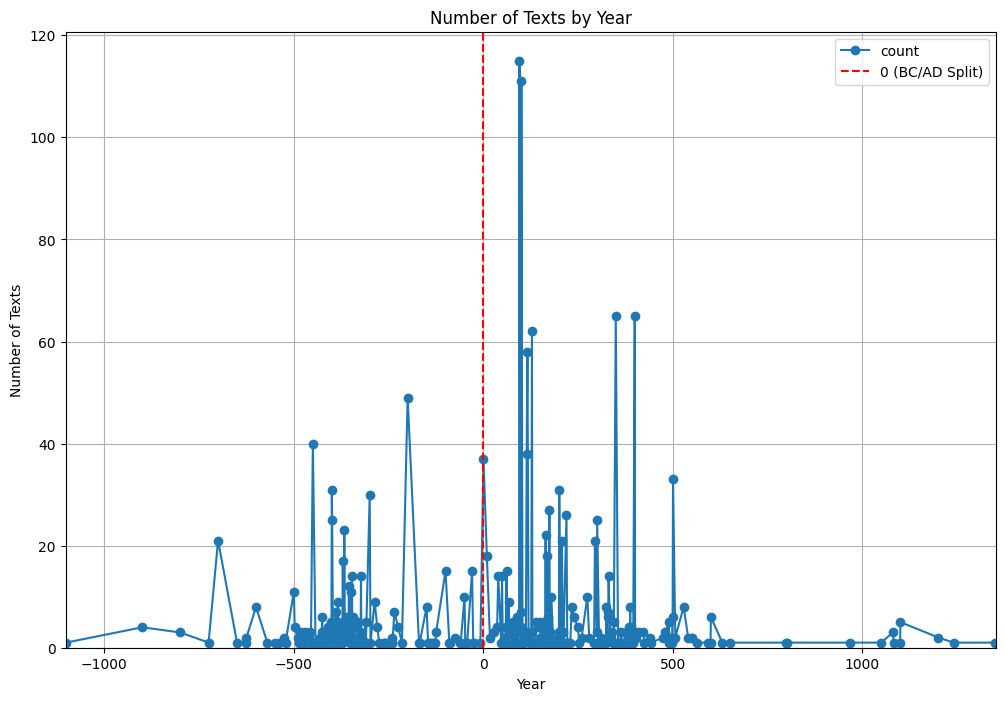

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Download the CSV file directly from the URL
url = "https://raw.githubusercontent.com/nauarchus/CATnaPS/refs/heads/public/metadata/naps_morph_datasets_datesorted.csv"

# Load the CSV data into a pandas DataFrame, ensuring all fields are read as strings (character)
df = pd.read_csv(url, dtype=str)

# Function to extract the start year from the formatted_work_date
def extract_start_year(date_range):
    try:
        # Extract the start date from the date range (before the '/')
        start_date = date_range.split('/')[0]

        # Print before any modifications to start_date for debugging
        print(f"Original start_date: {start_date}")

        # Use regular expressions to remove the month portion ("-MM" or "+MM")
        start_date = re.sub(r'-(\d{4})-\d{2}', r'-\1', start_date)  # Handles "-YYYY-MM"
        start_date = re.sub(r'\+(\d{4})-\d{2}', r'\1', start_date)   # Handles "+YYYY-MM"

        # Print after removing month portion for debugging
        print(f"After regex processing: {start_date}")

        # Check if the start_date is negative (BC year), and preserve the negative sign before removing leading zeroes
        if start_date.startswith('-'):
            start_date_lstripped = start_date  # Don't strip leading zeroes from negative years
        else:
            start_date_lstripped = start_date.lstrip('0')  # Strip leading zeroes only for positive years

        print(f"After conditional lstrip('0'): {start_date_lstripped}")  # Debugging: Show after conditional stripping

        # Convert to integer
        start_year = int(start_date_lstripped)
        print(f"Converted start_year: {start_year}")  # Debugging: Show the final parsed year

        return start_year
    except (ValueError, AttributeError):
        return None

# Apply the function to the formatted_work_date column
df['start_year'] = df['formatted_work_date'].apply(extract_start_year)

# Filter out rows where the start year is NaN (due to invalid date format)
df_cleaned = df.dropna(subset=['start_year'])

# Output the first two parsed years to debug
print("Sample parsed years:")
print(df_cleaned['start_year'].head(2))

# Check if we have any valid year data
if not df_cleaned.empty:
    # Group by start year and count the number of texts per year
    year_text_count = df_cleaned['start_year'].value_counts().sort_index(ascending=True)

    # Output the first two entries from the year count data to debug
    print("Sample year count data:")
    print(year_text_count.head(2))
    
    # Plot the number of texts by year as a line graph
    plt.figure(figsize=(12, 8))
    ax = year_text_count.plot(kind='line', marker='o')

    # Adjust the x-axis to have a 0 split between BC and AD
    ax.axvline(x=0, color='red', linestyle='--', label="0 (BC/AD Split)")  # Vertical line at 0
    ax.set_xlim(min(year_text_count.index) - 1, max(year_text_count.index) + 1)  # Ensure the axis includes all years

    plt.title("Number of Texts by Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Texts")
    plt.grid(True)
    
    # Set the Y axis to start at 0
    ax.set_ylim(bottom=0)

    # Display the legend
    plt.legend()

    plt.show()
else:
    print("No valid year data available to plot.")


## Compare Two Works: Identify Two cts_urn Values to Compare

For example, two works attributed to Severian of Gabala
pta0001.pta041
pta0001.pta042

In [2]:
# Hardcoded cts_urn values to filter
cts_urn_values = ['pta0001.pta041', 'pta0001.pta042']

# Filter the DataFrame to return rows where 'cts_urn' matches any of the specified values
filtered_df = df[df['cts_urn'].isin(cts_urn_values)]

# Set pandas options to display all columns
pd.set_option('display.max_columns', None)  # Show all columns

# Display the filtered rows
if not filtered_df.empty:
    print(filtered_df)  # Show the full DataFrame
else:
    print("No rows found for the given cts_urn values.")


     formatted_work_date         cts_urn              author  \
1777   +0400-01/+0409-12  pta0001.pta041  Severian of Gabala   
1778   +0400-01/+0409-12  pta0001.pta042  Severian of Gabala   

                                     title  start_year  
1777  In illud: Quando ipsi subiciet omnia         400  
1778          In illud: Genimina viperarum         400  


## Now Retrieve the Data and Run a Query against It

In [3]:
import pandas as pd

# Hardcoded cts_urn values to filter
cts_urn_values = ['pta0001.pta041', 'pta0001.pta042']

# Function to construct the raw GitHub URL based on the cts_urn
def construct_raw_url(cts_urn):
    author, work = cts_urn.split('.')
    url = f"https://raw.githubusercontent.com/nauarchus/AGDTmini/public/data/{author}/{work}/{author}.{work}.agdtm-grc1.csv"
    return url

# Retrieve datasets for each cts_urn and load them into pandas DataFrames
datasets = {}
for cts_urn in cts_urn_values:
    url = construct_raw_url(cts_urn)
    try:
        # Read the CSV from the constructed raw URL with the correct column names
        dataset = pd.read_csv(url, names=["location", "text"], header=None)
        datasets[cts_urn] = dataset
        print(f"Successfully retrieved data for {cts_urn}")
        # Optionally, display the first few rows of each dataset here to check
        print(dataset.head())
    except Exception as e:
        print(f"Failed to retrieve data for {cts_urn}: {e}")

# At this point, 'datasets' will contain the DataFrames for each cts_urn


Successfully retrieved data for pta0001.pta041
          location                                               text
0         location                                               text
1  ipsi.subiciet_1  χθές@d-------- ἐγώ@p1p---md- ἀδελφός@n-p---mv-...
2  ipsi.subiciet_2  ἀλλά@c-------- ’@c-------- ἐπεί@c-------- μέν@...
3  ipsi.subiciet_3  βιάζω@v-srpenn- φημί@v3spia--- ὁ@l-s---nn- ῥῆμ...
4  ipsi.subiciet_4  λαμβάνω@v2sama--- ἐγώ@p-s---md- καί@d-------- ...
Successfully retrieved data for pta0001.pta042
           location                                               text
0          location                                               text
1  Genim.viper._1.1  λαμπάς@n-s---fn- εὐσέβεια@n-s---fg- κήρυγμα@n-...
2  Genim.viper._1.2  ἔρχομαι@v1pasa--- τοίνυν@d-------- ἐπί@r------...
3  Genim.viper._1.3  εἰ@c-------- τοίνυν@d-------- σόδος@n-p---mg- ...
4  Genim.viper._1.4  ἀλλά@c-------- ’@c-------- εἰς@r-------- ὁ@l-s...
